<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/supervised/ES04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Provide an archive containing the report and the developed code to obtain the best performance on the full dataset provided:

BOW parameters should be tuned by you (image size, grid size, number of centroids, number of training images).
The maximum number of training images is 70, since the last 30 have to be used for testing
You can also experiment with a different classifier instead of the 1-NN provided, but it is more important to experiment with BOW parameters
Provide in the report the best parameter configuration obtained, the final accuracy, the confusion matrix, and a short comment about the type of classification errors that your model is doing

Archive:  image.orig_minimal.zip
   creating: image.orig_minimal/
  inflating: __MACOSX/._image.orig_minimal  
  inflating: image.orig_minimal/200.jpg  
  inflating: __MACOSX/image.orig_minimal/._200.jpg  
  inflating: image.orig_minimal/201.jpg  
  inflating: __MACOSX/image.orig_minimal/._201.jpg  
  inflating: image.orig_minimal/203.jpg  
  inflating: __MACOSX/image.orig_minimal/._203.jpg  
  inflating: image.orig_minimal/202.jpg  
  inflating: __MACOSX/image.orig_minimal/._202.jpg  
  inflating: image.orig_minimal/206.jpg  
  inflating: __MACOSX/image.orig_minimal/._206.jpg  
  inflating: image.orig_minimal/.DS_Store  
  inflating: __MACOSX/image.orig_minimal/._.DS_Store  
  inflating: image.orig_minimal/207.jpg  
  inflating: __MACOSX/image.orig_minimal/._207.jpg  
  inflating: image.orig_minimal/8.jpg  
  inflating: __MACOSX/image.orig_minimal/._8.jpg  
  inflating: image.orig_minimal/205.jpg  
  inflating: __MACOSX/image.orig_minimal/._205.jpg  
  inflating: image.orig_minimal/20

In [2]:
import os
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from google.colab import drive


In [3]:
# load the dataset
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [6]:
!unzip /content/drive/MyDrive/Supervised/ES04/image.orig_minimal.zip


Archive:  /content/drive/MyDrive/Supervised/ES04/image.orig_minimal.zip
   creating: image.orig_minimal/
  inflating: __MACOSX/._image.orig_minimal  
  inflating: image.orig_minimal/200.jpg  
  inflating: __MACOSX/image.orig_minimal/._200.jpg  
  inflating: image.orig_minimal/201.jpg  
  inflating: __MACOSX/image.orig_minimal/._201.jpg  
  inflating: image.orig_minimal/203.jpg  
  inflating: __MACOSX/image.orig_minimal/._203.jpg  
  inflating: image.orig_minimal/202.jpg  
  inflating: __MACOSX/image.orig_minimal/._202.jpg  
  inflating: image.orig_minimal/206.jpg  
  inflating: __MACOSX/image.orig_minimal/._206.jpg  
  inflating: image.orig_minimal/.DS_Store  
  inflating: __MACOSX/image.orig_minimal/._.DS_Store  
  inflating: image.orig_minimal/207.jpg  
  inflating: __MACOSX/image.orig_minimal/._207.jpg  
  inflating: image.orig_minimal/8.jpg  
  inflating: __MACOSX/image.orig_minimal/._8.jpg  
  inflating: image.orig_minimal/205.jpg  
  inflating: __MACOSX/image.orig_minimal/._205.j

In [7]:
#---- PARAMETERS: TBD
featStep = 50
imsize = 500
Nim4training = 7 # fixed to 70 on the complete dataset
K = 100

In [8]:
# grid creation
pointPositions = np.array([[float(ii), float(jj)]
                           for ii in range(featStep, imsize-featStep, featStep)
                           for jj in range(featStep, imsize-featStep, featStep)])
print(f'Total points: {len(pointPositions)}')

Total points: 64


In [9]:
# feature extraction
features = []
labels = []
sift = cv2.SIFT_create()

start_time = time.time()

for class_idx in range(3):
  for nimage in range(Nim4training):
    img_path = f'./image.orig_minimal/{100*class_idx + nimage}.jpg'
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (imsize, imsize))
    keypoints = [cv2.KeyPoint(x, y, 1) for x, y in pointPositions]
    keypoints, descriptors = sift.compute(img, keypoints)
    features.append(descriptors)
    labels.append(np.column_stack((np.full(len(descriptors), class_idx),
                                   np.full(len(descriptors), nimage))))

print(f'Feature extraction completed in {time.time() - start_time:.2f}')

features = np.vstack(features)
labels = np.vstack(labels)

Feature extraction completed in 0.53


In [10]:
labels.shape

(1344, 2)

In [11]:
features.shape

(1344, 128)

In [12]:
labels

array([[0, 0],
       [0, 0],
       [0, 0],
       ...,
       [2, 6],
       [2, 6],
       [2, 6]])

In [13]:
# kmeans clustering
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10) # ----> TBD
start_time = time.time()
IDX = kmeans.fit_predict(features)
C = kmeans.cluster_centers_
print(f'Kmeans clustering completed in {time.time() - start_time:.2f}')


Kmeans clustering completed in 1.85


In [14]:
# BOW histograms for training images
BOW_tr = []
labels_tr = []

for class_idx in range(3):
  for nimage in range(Nim4training):
    u = np.where((labels[:,0] == class_idx) & (labels[:,1] == nimage))[0]
    imfeaturesIDX = IDX[u]
    H, _ = np.histogram(imfeaturesIDX, bins=np.arange(K+1), density=True)
    BOW_tr.append(H)
    labels_tr.append(class_idx)
BOW_tr = np.array(BOW_tr)
labels_tr = np.array(labels_tr)


In [15]:
# BOW histograms for testing images
BOW_te = []
labels_te = []

for class_idx in range(3):
  for nimage in range(Nim4training, 10):
    img_path = f'./image.orig_minimal/{100*class_idx + nimage}.jpg'
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (imsize, imsize))
    keypoints = [cv2.KeyPoint(x, y, 1) for x, y in pointPositions]
    keypoints, descriptors = sift.compute(img, keypoints)

    D = np.linalg.norm(descriptors[:, np.newaxis] -C, axis=2)
    words = np.argmin(D, axis=1)
    H, _ = np.histogram(words, bins=np.arange(K+1), density=True)
    BOW_te.append(H)
    labels_te.append(class_idx)

BOW_te = np.array(BOW_te)
labels_te = np.array(labels_te)

In [ ]:
BOW_te.shape

(9, 100)

In [16]:
# classification ----> TBD
predicted_class = []

for H in BOW_te:
  distances = np.linalg.norm(BOW_tr - H, axis=1)
  u = np.argmin(distances)
  predicted_class.append(labels_tr[u])

predicted_class = np.array(predicted_class)

In [17]:
predicted_class

array([0, 0, 0, 2, 1, 1, 2, 2, 2])

Accuracy: 0.89


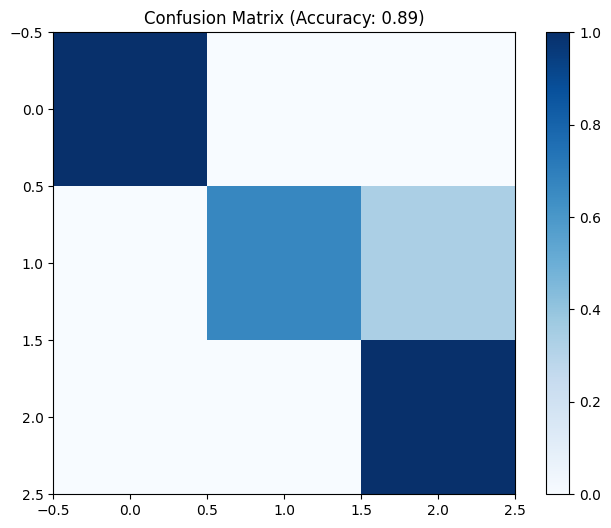

In [18]:
# performance measurement
CM = confusion_matrix(labels_te, predicted_class, normalize='true')
accuracy = np.mean(np.diag(CM))

print(f'Accuracy: {accuracy:.2f}')
plt.figure(figsize=(8,6))
plt.imshow(CM, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2f})')
plt.show()